<a href="https://colab.research.google.com/github/mathangivs22/faiProject/blob/main/Capstone_MileStone3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Temporal Difference Experiment

##Paper :Learning to Predict by the Methods of Temporal Differences By Richard Sutton

##Setting up the a generic random walk environment as done in paper

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Setting up basic random walk-environment as done in Sutton's paper
class RandomWalk:
    def __init__(self, no_states=5):
        self.no_states = no_states
        self.start_state = no_states // 2 + 1  # middle state (state 3 for 5-state)
        self.terminal_left = 0
        self.terminal_right = no_states + 1

    def reset(self):
        self.state = self.start_state
        return self.state

    def step(self):
        move = np.random.choice([-1, 1])
        next_state = self.state + move
        reward = 1 if next_state == self.terminal_right else 0
        done = (next_state == self.terminal_left or next_state == self.terminal_right)
        self.state = next_state
        return next_state, reward, done


## Implemented an unified method to handle both TD(0) and Monte Carlo methods.

In [1]:
def td_unified(env, episodes=100, alpha=0.1, gamma=1.0, lam=0):
    n = env.no_states + 2
    V = np.zeros(n)       # terminals stay 0 — they are absorbing states
    rms_errors = []

    # true values for 5-state random walk (Sutton & Barto)
    true_V = np.zeros(n)
    true_V[1:-1] = np.arange(1, env.no_states + 1) / (env.no_states + 1)

    for ep in range(episodes):
        state = env.reset()
        done = False
        eligibility = np.zeros(n)
        states, rewards = [], []

        while not done:
            next_state, reward, done = env.step()

            if lam < 1:  # TD(0) or TD(lambda)
                delta = reward + gamma * V[next_state] - V[state]
                eligibility[state] += 1
                V += alpha * delta * eligibility
                eligibility *= gamma * lam
                state = next_state

            else:  # Monte Carlo
                states.append(state)
                rewards.append(reward)
                state = next_state

                if done:
                    G = 0
                    visited = set()
                    for t in reversed(range(len(states))):
                        G = rewards[t] + gamma * G
                        s = states[t]
                        if s not in visited:
                          visited.add(s)
                          V[s] += alpha * (G - V[s])

        rms_errors.append(np.sqrt(np.mean((V[1:-1] - true_V[1:-1])**2)))

    return V, rms_errors

##Results to find the values generated , if the models have learnt in the right manner.

In [ ]:
# run multiple times and average to get stable values
results_td0 = []
results_mc  = []
true_V = np.zeros(7)
true_V[1:-1] = np.arange(1, 6) / 6  # for 5-state walk

for _ in range(100):
    env = RandomWalk(no_states=5)  # fresh env each time
    V_td0, _ = td_unified(env, lam=0,   alpha=0.05, episodes=1000)
    V_mc,  _ = td_unified(env, lam=1.0, alpha=0.1, episodes=1000)
    results_td0.append(V_td0)
    results_mc.append(V_mc)

print("TD(0) avg V:", np.round(np.mean(results_td0, axis=0), 3))
print("MC    avg V:", np.round(np.mean(results_mc,  axis=0), 3))
print("True  V:    ", np.round(true_V, 3))

TD(0) avg V: [0.    0.152 0.316 0.496 0.668 0.844 0.   ]
MC    avg V: [0.    0.163 0.337 0.507 0.672 0.835 0.   ]
True  V:     [0.    0.167 0.333 0.5   0.667 0.833 0.   ]


##Plotting graphs with different lambda values , to compare their learning patterns:

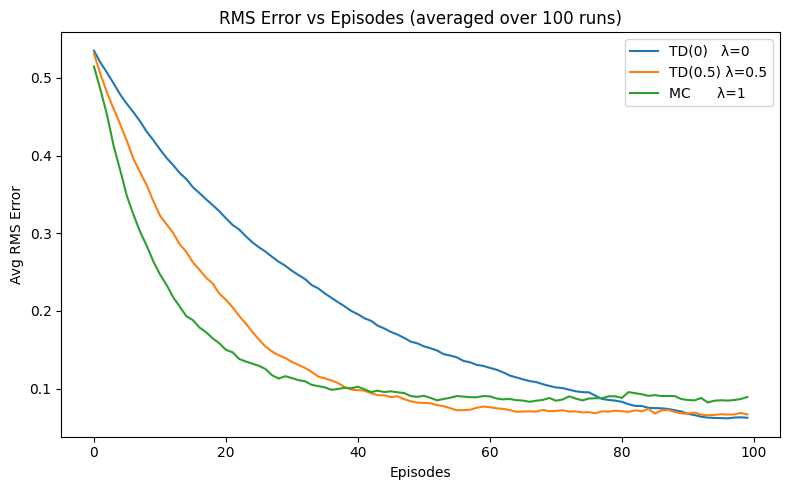

In [ ]:
runs = 100
all_td0, all_td05, all_mc = [], [], []
env = RandomWalk(no_states=5)

for _ in range(runs):
    _, rms = td_unified(env, lam=0,   alpha=0.1)
    all_td0.append(rms)
    _, rms = td_unified(env, lam=0.5, alpha=0.1)
    all_td05.append(rms)
    _, rms = td_unified(env, lam=1.0, alpha=0.1)
    all_mc.append(rms)

plt.figure(figsize=(8, 5))
plt.plot(np.mean(all_td0,  axis=0), label="TD(0)   λ=0")
plt.plot(np.mean(all_td05, axis=0), label="TD(0.5) λ=0.5")
plt.plot(np.mean(all_mc,   axis=0), label="MC      λ=1")
plt.xlabel("Episodes")
plt.ylabel("Avg RMS Error")
plt.title("RMS Error vs Episodes (averaged over 100 runs)")
plt.legend()
plt.tight_layout()
plt.show()

##Explicitly plotting the graph for TD(0) and TD(1)(Monte Carlo):

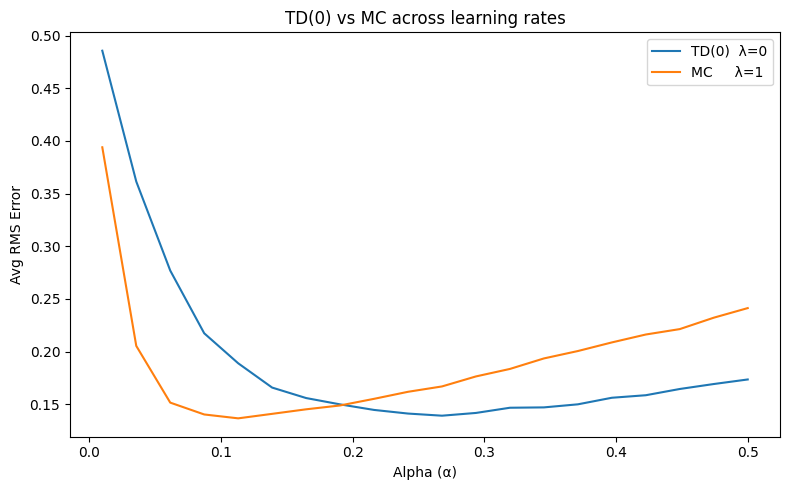

In [ ]:
alphas = np.linspace(0.01, 0.5, 20)
td0_final, mc_final = [], []

for alpha in alphas:
    td0_runs, mc_runs = [], []
    for _ in range(runs):
        _, rms = td_unified(env, lam=0,   alpha=alpha)
        td0_runs.append(np.mean(rms))
        _, rms = td_unified(env, lam=1.0, alpha=alpha)
        mc_runs.append(np.mean(rms))
    td0_final.append(np.mean(td0_runs))
    mc_final.append(np.mean(mc_runs))
plt.figure(figsize=(8, 5))
plt.plot(alphas, td0_final, label="TD(0)  λ=0")
plt.plot(alphas, mc_final,  label="MC     λ=1")
plt.xlabel("Alpha (α)")
plt.ylabel("Avg RMS Error")
plt.title("TD(0) vs MC across learning rates")
plt.legend()
plt.tight_layout()
plt.show()

## Generated a table for comparsion of stability, RMS error,Standard Deviation and Convergence of Episode:

### An environment with 5 state setup:

In [ ]:
env = RandomWalk(no_states=5)
runs = 100
lambdas = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

print(f"{'λ':<8} {'Final RMS':>10} {'Conv Episode':>14} {'Total Error':>12} {'Std Dev':>10}")
print("-" * 58)

for lam in lambdas:
    all_runs = []
    for _ in range(runs):
        _, rms = td_unified(env, lam=lam, alpha=0.1, episodes=100)
        all_runs.append(rms)

    avg_rms = np.mean(all_runs, axis=0)
    std_rms = np.std(all_runs, axis=0)

    final_rms  = avg_rms[-1]                          # convergence quality
    conv_ep    = next((i for i, r in enumerate(avg_rms) if r < 0.20), 100)  # speed
    total_err  = np.sum(avg_rms)                      # efficiency
    avg_std    = np.mean(std_rms)                     # stability

    print(f"{lam:<8} {final_rms:>10.4f} {conv_ep:>14} {total_err:>12.2f} {avg_std:>10.4f}")

λ         Final RMS   Conv Episode  Total Error    Std Dev
----------------------------------------------------------
0            0.0659             39        20.17     0.0402
0.2          0.0636             31        17.51     0.0401
0.4          0.0646             26        15.50     0.0437
0.6          0.0762             19        13.79     0.0453
0.8          0.0890             13        13.29     0.0535
1.0          0.0987             15        13.86     0.0514


### An environment with 10 state setup:

In [ ]:
env = RandomWalk(no_states=10)
runs = 100
lambdas = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

print(f"{'λ':<8} {'Final RMS':>10} {'Conv Episode':>14} {'Total Error':>12} {'Std Dev':>10}")
print("-" * 58)

for lam in lambdas:
    all_runs = []
    for _ in range(runs):
        _, rms = td_unified(env, lam=lam, alpha=0.1, episodes=100)
        all_runs.append(rms)

    avg_rms = np.mean(all_runs, axis=0)
    std_rms = np.std(all_runs, axis=0)

    final_rms  = avg_rms[-1]                          # convergence quality
    conv_ep    = next((i for i, r in enumerate(avg_rms) if r < 0.20), 100)  # speed
    total_err  = np.sum(avg_rms)                      # efficiency
    avg_std    = np.mean(std_rms)                     # stability

    print(f"{lam:<8} {final_rms:>10.4f} {conv_ep:>14} {total_err:>12.2f} {avg_std:>10.4f}")

λ         Final RMS   Conv Episode  Total Error    Std Dev
----------------------------------------------------------
0            0.1393             73        29.93     0.0257
0.2          0.1029             59        26.40     0.0297
0.4          0.0753             45        22.24     0.0319
0.6          0.0551             30        17.10     0.0384
0.8          0.0731             17        13.59     0.0436
1.0          0.0898             14        13.42     0.0471


##Final predictions:
λ=0.0  → most stable, good accuracy, slow starter
λ=0.2  → best final accuracy, nearly as stable as TD(0) ← sweet spot
λ=0.4  → decent all-rounder, starting to lose accuracy
λ=0.6  → most sample efficient but accuracy degrading
λ=0.8  → fast but unreliable, accuracy quite poor
λ=1.0  → fastest start, worst final accuracy, most unstable

## Observations from the result:
Final conclusion is from stability point of view TD(0) is the best it takes time to converge but is stable for higher values of alpha(learning rates). Whereas MonteCarlo appears to be better around 50 episodes but as the alpha value increase it becomes unstable and then lands with a higher avgerage RMS error than TD(0). As we are taking very few episodes there will be fluctuations, as TD(0) needs lot of episodes to learn from , Monte Carlo is unbaised and needs few episodes but stability might not be guarnateed.Also alpha rates matter for TD(0) , alpha of 0.05 is the good value or sweet spot where we are getting right result but for MC alpha =0.1 higher learning rate is preferred.

For simple short environments — TD(0) is the best overall choice, winning on accuracy and stability simultaneously.
For longer more complex environments — λ=0.2 offers a slight accuracy improvement over TD(0) while maintaining nearly the same stability, making it the practical sweet spot.
MC should be avoided in both cases — it is the fastest to show initial progress but converges to the worst final accuracy and is the most unstable method by a significant margin.